<a href="https://colab.research.google.com/github/dae-gwang/food-ai-practice-/blob/main/%EC%9D%B4%EB%AF%B8%EC%A7%80%EB%8D%B0%EC%9D%B4%ED%84%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("이미지 데이터 구조 탐색용 라이브러리 로드 완료")

이미지 데이터 구조 탐색용 라이브러리 로드 완료


In [ ]:
!mkdir -p /content/rice_leaf_data
print("현재 /content 폴더 안 파일과 폴더:")
print(os.listdir("/content"))

현재 /content 폴더 안 파일과 폴더:
['.config', 'rice_leaf_data', 'sample_data']


In [ ]:
!wget -O /content/rice_leaf_data/rice_leaf_diseases.zip "https://archive.ics.uci.edu/static/public/486/rice+leaf+diseases.zip"

print("rice_leaf_data 폴더 안 파일:")
print(os.listdir("/content/rice_leaf_data"))

--2026-05-14 04:53:25--  https://archive.ics.uci.edu/static/public/486/rice+leaf+diseases.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/rice_leaf_data/rice_leaf_diseases.zip’

/content/rice_leaf_     [      <=>           ]  36.66M  31.3MB/s    in 1.2s    

2026-05-14 04:53:27 (31.3 MB/s) - ‘/content/rice_leaf_data/rice_leaf_diseases.zip’ saved [38442567]

rice_leaf_data 폴더 안 파일:
['rice_leaf_diseases.zip']


In [ ]:
!unzip -q /content/rice_leaf_data/rice_leaf_diseases.zip \-d /content/rice_leaf_data/unzipped
print("압축 해제 후 rice_leaf_data 폴더:")
print(os.listdir("/content/rice_leaf_data"))

압축 해제 후 rice_leaf_data 폴더:
['rice_leaf_diseases.zip', 'unzipped']


In [ ]:
base_dir = Path("/content/rice_leaf_data/unzipped")
print("최상위 폴더/파일:")
for item in base_dir.glob("*"):
    print(item)

최상위 폴더/파일:
/content/rice_leaf_data/unzipped/Brown spot
/content/rice_leaf_data/unzipped/Bacterial leaf blight
/content/rice_leaf_data/unzipped/Leaf smut


In [ ]:
for root, dirs, files in os.walk(base_dir):
 print("현재 폴더:", root)
 print("하위 폴더:", dirs)
 print("파일 개수:", len(files))
 print("-" * 50)

현재 폴더: /content/rice_leaf_data/unzipped
하위 폴더: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']
파일 개수: 0
--------------------------------------------------
현재 폴더: /content/rice_leaf_data/unzipped/Brown spot
하위 폴더: []
파일 개수: 40
--------------------------------------------------
현재 폴더: /content/rice_leaf_data/unzipped/Bacterial leaf blight
하위 폴더: []
파일 개수: 40
--------------------------------------------------
현재 폴더: /content/rice_leaf_data/unzipped/Leaf smut
하위 폴더: []
파일 개수: 40
--------------------------------------------------


In [ ]:
image_extensions = (".jpg", ".jpeg", ".png")
for root, dirs, files in os.walk(base_dir):
    image_files = [f for f in files
                   if f.lower().endswith(image_extensions)]
    if len(image_files) > 0:
        print("이미지 포함 폴더:", root)
        print("이미지 파일 수:", len(image_files))
        print("예시 파일:", image_files[:3])
        print("-" * 50)

이미지 포함 폴더: /content/rice_leaf_data/unzipped/Brown spot
이미지 파일 수: 40
예시 파일: ['DSC_0104.jpg', 'DSC_0329.jpg', 'DSC_0108.jpg']
--------------------------------------------------
이미지 포함 폴더: /content/rice_leaf_data/unzipped/Bacterial leaf blight
이미지 파일 수: 40
예시 파일: ['DSC_0398.JPG', 'DSC_0366.jpg', 'DSC_0388.JPG']
--------------------------------------------------
이미지 포함 폴더: /content/rice_leaf_data/unzipped/Leaf smut
이미지 파일 수: 40
예시 파일: ['DSC_0505.jpg', 'DSC_0321.JPG', 'DSC_0314.JPG']
--------------------------------------------------


In [ ]:
class_dirs = []
for root, dirs, files in os.walk(base_dir):
    image_files = [f for f in files
                   if f.lower().endswith(image_extensions)]
    if len(image_files) > 0:
        class_dirs.append(root)
print("클래스 폴더 수:", len(class_dirs))
for d in class_dirs:
    print(d)

클래스 폴더 수: 3
/content/rice_leaf_data/unzipped/Brown spot
/content/rice_leaf_data/unzipped/Bacterial leaf blight
/content/rice_leaf_data/unzipped/Leaf smut


In [ ]:
class_counts = defaultdict(int)
for d in class_dirs:
  class_name = Path(d).name
  image_files = []
  for ext in image_extensions:
    image_files.extend(list(Path(d).glob(f"*{ext}")))
    image_files.extend(list(Path(d).glob(f"*{ext.upper()
}")))
  class_counts[class_name] += len(image_files)

print("클래스별 이미지 개수")
print(dict(class_counts))

클래스별 이미지 개수
{'Brown spot': 40, 'Bacterial leaf blight': 40, 'Leaf smut': 40}


In [ ]:
class_count_df = pd.DataFrame({
  "class_name": list(class_counts.keys()),
  "image_count": list(class_counts.values())
})
display(class_count_df)

,class_name,image_count
0,Brown spot,40
1,Bacterial leaf blight,40
2,Leaf smut,40


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

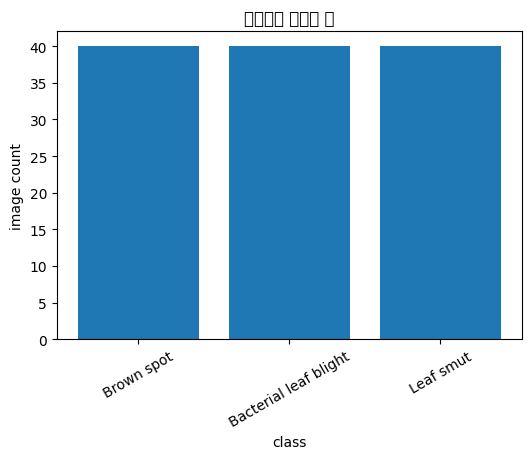

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(class_count_df["class_name"],
         class_count_df["image_count"])
plt.xticks(rotation=30)
plt.title("클래스별 이미지 수")
plt.xlabel("class")
plt.ylabel("image count")
plt.show()

In [ ]:
first_class_dir = Path(class_dirs[0])
first_image_path = None
for ext in image_extensions:
  files = (list(first_class_dir.glob(f"*{ext}")) +
           list(first_class_dir.glob(f"*{ext.upper()}")))
  if len(files) > 0:
       first_image_path = files[0]
       break
print("첫 번째 클래스 폴더:", first_class_dir)
print("첫 번째 이미지 경로:", first_image_path)

첫 번째 클래스 폴더: /content/rice_leaf_data/unzipped/Brown spot
첫 번째 이미지 경로: /content/rice_leaf_data/unzipped/Brown spot/DSC_0104.jpg


이미지 타입: <class 'PIL.JpegImagePlugin.JpegImageFile'>
이미지 크기: (1530, 371)
이미지 모드: RGB


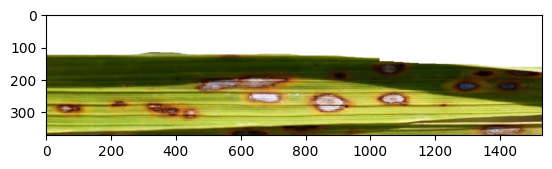

In [ ]:
img = Image.open(first_image_path)
print("이미지 타입:", type(img))
print("이미지 크기:", img.size)
print("이미지 모드:", img.mode)
plt.imshow(img)
plt.axis("on")
plt.show()

In [ ]:
sample_paths = []
for d in class_dirs:
 class_name = Path(d).name
 image_files = []
 for ext in image_extensions:
  image_files.extend(list(Path(d).glob(f"*{ext}")))
  image_files.extend(list(Path(d).glob(f"*{ext.upper()
}")))
 if len(image_files) > 0:
  sample_paths.append((class_name, image_files[0]))
for class_name, img_path in sample_paths:
   img = Image.open(img_path)
   print(class_name, ":", img.size, img.mode)

Brown spot : (1530, 371) RGB
Bacterial leaf blight : (3081, 897) RGB
Leaf smut : (946, 255) RGB


In [ ]:
img_array = np.array(img)
print("이미지 객체 타입:", type(img))
print("NumPy 배열 타입:", type(img_array))
print("배열 shape:", img_array.shape)
print("배열 값의 최솟값:", img_array.min())
print("배열 값의 최댓값:", img_array.max())

이미지 객체 타입: <class 'PIL.JpegImagePlugin.JpegImageFile'>
NumPy 배열 타입: <class 'numpy.ndarray'>
배열 shape: (255, 946, 3)
배열 값의 최솟값: 0
배열 값의 최댓값: 255


원본 크기: (3081, 897)
변경 후 크기: (128, 128)


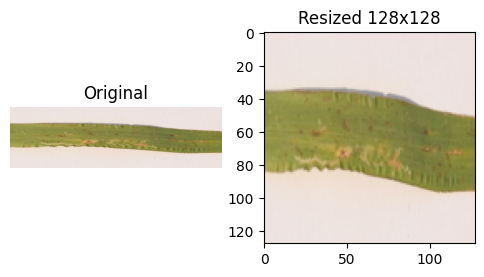

In [ ]:
resized_img = img.resize((128, 128))
print("원본 크기:", img.size)
print("변경 후 크기:", resized_img.size)
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title("Resized 128x128")
plt.axis("on")
plt.show()

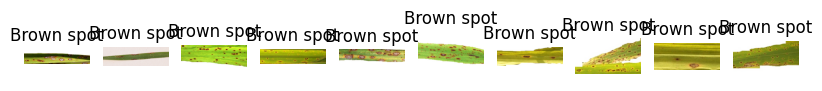

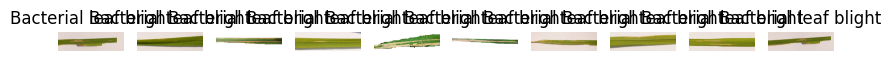

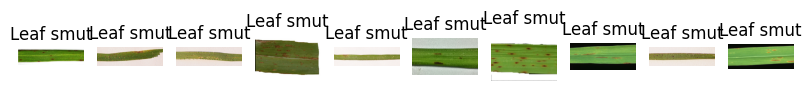

In [ ]:
num_images_per_class = 10
for d in class_dirs:
 class_name = Path(d).name
 image_files = []
 for ext in image_extensions:
  image_files.extend(list(Path(d).glob(f"*{ext}")))
  image_files.extend(list(Path(d).glob(f"*{ext.upper()
}")))
 plt.figure(figsize=(10, 3))
 for i, img_path in enumerate(
  image_files[:num_images_per_class], start=1):
  img = Image.open(img_path)
  plt.subplot(1, num_images_per_class, i)
  plt.imshow(img)
  plt.title(class_name)
  plt.axis("off")
plt.show()